# Importing Files

In [1]:
import pandas as pd

files = [
    "../Data/Raw/customers.csv",
    "../Data/Raw/orders.csv",
    "../Data/Raw/order_items.csv",
    "../Data/Raw/order_payments.csv",
    "../Data/Raw/order_reviews.csv",
    "../Data/Raw/products.csv",
    "../Data/Raw/sellers.csv",
    "../Data/Raw/geolocation.csv",
    "../Data/Raw/product_category_name_translation.csv"
]

for file in files:
    df = pd.read_csv(file)
    print(f"\n{file}")
    print(df.shape)
    print(df.columns.tolist())


../Data/Raw/customers.csv
(99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

../Data/Raw/orders.csv
(99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

../Data/Raw/order_items.csv
(112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

../Data/Raw/order_payments.csv
(103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

../Data/Raw/order_reviews.csv
(99224, 7)
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

../Data/Raw/products.csv
(32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight

In [2]:
import pandas as pd

customers = pd.read_csv('../Data/Raw/customers.csv')
orders = pd.read_csv('../Data/Raw/orders.csv')
order_items = pd.read_csv('../Data/Raw/order_items.csv')
order_payments = pd.read_csv('../Data/Raw/order_payments.csv')
order_reviews = pd.read_csv('../Data/Raw/order_reviews.csv')
products = pd.read_csv('../Data/Raw/products.csv')
sellers = pd.read_csv('../Data/Raw/sellers.csv')
geolocation = pd.read_csv('../Data/Raw/geolocation.csv')
product_category_name_translation = pd.read_csv('../Data/Raw/product_category_name_translation.csv')

# Check Data for Null, Duplicate

In [3]:
for file in files:
    df = pd.read_csv(file)
    print(file)
    print('-' * 10)
    print(df.isnull().sum())
    print(' ')

../Data/Raw/customers.csv
----------
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
 
../Data/Raw/orders.csv
----------
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
 
../Data/Raw/order_items.csv
----------
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
 
../Data/Raw/order_payments.csv
----------
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
 
../Data/Raw/order_reviews.csv

In [4]:

for file in files:
    df = pd.read_csv(file)
    print(file)
    print(df.duplicated().sum())
    print(' ')

../Data/Raw/customers.csv
0
 
../Data/Raw/orders.csv
0
 
../Data/Raw/order_items.csv
0
 
../Data/Raw/order_payments.csv
0
 
../Data/Raw/order_reviews.csv
0
 
../Data/Raw/products.csv
0
 
../Data/Raw/sellers.csv
0
 
../Data/Raw/geolocation.csv
261831
 
../Data/Raw/product_category_name_translation.csv
0
 


In [5]:
orders['order_status'].unique()

<StringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [6]:
orders[orders['order_approved_at'].isnull()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [7]:
orders[orders['order_delivered_carrier_date'].isnull()]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [8]:
products[products['product_category_name'].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [9]:
products = products.dropna()

In [10]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

# Customer Segmentation (RFM Analysis)

In [11]:
import pandas as pd

rfm = pd.read_csv("../Data/Processed/rfm_base.csv")

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


In [12]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93357 non-null  str    
 1   last_purchase       93357 non-null  str    
 2   frequency           93357 non-null  int64  
 3   monetary            93357 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 2.8 MB


In [13]:
rfm["last_purchase"] = pd.to_datetime(
    rfm["last_purchase"]
)

snapshot_date = (
    rfm["last_purchase"].max()
    + pd.Timedelta(days=1)
)

In [14]:
rfm["recency"] = (
    snapshot_date
    - rfm["last_purchase"]
).dt.days

In [15]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93357 non-null  str           
 1   last_purchase       93357 non-null  datetime64[us]
 2   frequency           93357 non-null  int64         
 3   monetary            93357 non-null  float64       
 4   recency             93357 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 MB


In [16]:
rfm.head()


,customer_unique_id,last_purchase,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288


In [17]:
rfm.describe()


,last_purchase,frequency,monetary,recency
count,93357,93357.000000,93357.000000,93357.000000
mean,2018-01-04 03:54:56.246505,1.033420,165.198772,237.936673
min,2016-10-03 16:56:50,1.000000,9.590000,1.000000
25%,2017-09-17 18:27:12,1.000000,63.060000,114.000000
50%,2018-01-23 00:18:46,1.000000,107.780000,219.000000
75%,2018-05-07 17:23:11,1.000000,182.560000,346.000000
max,2018-08-29 15:00:37,15.000000,13664.080000,695.000000
std,NaN,0.209099,226.314579,152.584315


In [18]:
rfm.shape

(93357, 5)

# RFM Scoring

In [19]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5,4,3,2,1]
)

In [20]:
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [21]:
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1,2,3,4,5]
)

In [22]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

In [23]:
rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115,4,1,1,411
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288,2,1,4,214


In [24]:
rfm[
[
'R_score',
'F_score',
'M_score'
]
].describe()

,R_score,F_score,M_score
count,93357,93357,93357
unique,5,5,5
top,5,1,2
freq,18728,18672,18683


In [25]:
rfm['RFM_Score'].value_counts().head(20)

RFM_Score
555    1000
455     960
255     896
355     888
222     859
155     850
242     843
424     837
531     836
131     826
331     823
344     815
454     814
112     806
121     805
142     805
132     804
544     801
341     800
111     799
Name: count, dtype: int64

In [26]:
def segment_customer(row):

    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r == 5 and f == 1:
        return "New Customers"

    elif r >= 3 and f == 1:
        return "Promising"

    elif r == 2 and f >= 2:
        return "Need Attention"

    elif r == 1 and f >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

In [27]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [28]:
rfm["Segment"].value_counts()

Segment
Lost Customers         18635
Loyal Customers        16047
Potential Loyalists    14993
Need Attention         14921
At Risk                11079
Promising               7469
Champions               6493
New Customers           3720
Name: count, dtype: int64

In [29]:
rfm["Segment"].value_counts(normalize=True) * 100

Segment
Lost Customers         19.961010
Loyal Customers        17.188856
Potential Loyalists    16.059856
Need Attention         15.982733
At Risk                11.867348
Promising               8.000471
Champions               6.955022
New Customers           3.984704
Name: proportion, dtype: float64

In [30]:
segment_summary = (
    rfm.groupby("Segment")
       .agg({
           "recency": "mean",
           "frequency": "mean",
           "monetary": "mean"
       })
       .round(2)
)

segment_summary

,recency,frequency,monetary
Segment,,,
At Risk,473.35,1.04,164.54
Champions,91.11,1.18,312.13
Lost Customers,341.76,1.00,157.70
Loyal Customers,151.49,1.05,115.48
Need Attention,316.50,1.04,168.57
New Customers,45.95,1.00,160.77
Potential Loyalists,90.61,1.00,164.90
Promising,177.50,1.00,160.06


# Customer Lifetime Value (CLV)

In [31]:
rfm["AOV"] = rfm["monetary"] / rfm["frequency"]
rfm[["frequency", "monetary", "AOV"]].head()

,frequency,monetary,AOV
0,1,141.90,141.90
1,1,27.19,27.19
2,1,86.22,86.22
3,1,43.62,43.62
4,1,196.89,196.89


In [32]:
rfm["AOV"].describe()

count    93357.000000
mean       160.316648
std        219.572062
min          9.590000
25%         62.370000
50%        105.630000
75%        176.650000
max      13664.080000
Name: AOV, dtype: float64

In [33]:
top_customer = (
    rfm.sort_values(
        by="monetary",
        ascending=False
    )
    .head(10)
)

top_customer[
    [
        "customer_unique_id",
        "frequency",
        "monetary",
        "AOV",
        "Segment"
    ]
]

,customer_unique_id,frequency,monetary,AOV,Segment
3724,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.0800,Lost Customers
79635,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.8150,At Risk
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.8800,Potential Loyalists
80462,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.3100,At Risk
25436,459bef486812aa25204be022145caa62,1,6922.21,6922.2100,Potential Loyalists
93080,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.6600,At Risk
23411,4007669dec559734d6f53e029e360987,1,6081.54,6081.5400,Need Attention
87147,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.3400,At Risk
26640,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.7800,Potential Loyalists
73126,c8460e4251689ba205045f3ea17884a1,4,4655.91,1163.9775,Champions


In [34]:
clv_summary = (
    rfm.groupby("Segment")
       .agg({
           "customer_unique_id": "count",
           "monetary": "mean",
           "AOV": "mean",
           "frequency": "mean"
       })
       .rename(columns={
           "customer_unique_id": "Total Customers",
           "monetary": "Avg Customer Value",
           "AOV": "Avg Order Value",
           "frequency": "Avg Frequency"
       })
       .round(2)
)

clv_summary

,Total Customers,Avg Customer Value,Avg Order Value,Avg Frequency
Segment,,,,
At Risk,11079,164.54,158.82,1.04
Champions,6493,312.13,281.54,1.18
Lost Customers,18635,157.70,157.70,1.00
Loyal Customers,16047,115.48,108.78,1.05
Need Attention,14921,168.57,162.79,1.04
New Customers,3720,160.77,160.77,1.00
Potential Loyalists,14993,164.90,164.90,1.00
Promising,7469,160.06,160.06,1.00


In [ ]:
clv_summary.head()

,Total Customers,Avg Customer Value,Avg Order Value,Avg Frequency,Segment
Segment,,,,,
Champions,6493,312.13,281.54,1.18,NaN
Need Attention,14921,168.57,162.79,1.04,NaN
Potential Loyalists,14993,164.90,164.90,1.00,NaN
At Risk,11079,164.54,158.82,1.04,NaN
New Customers,3720,160.77,160.77,1.00,NaN


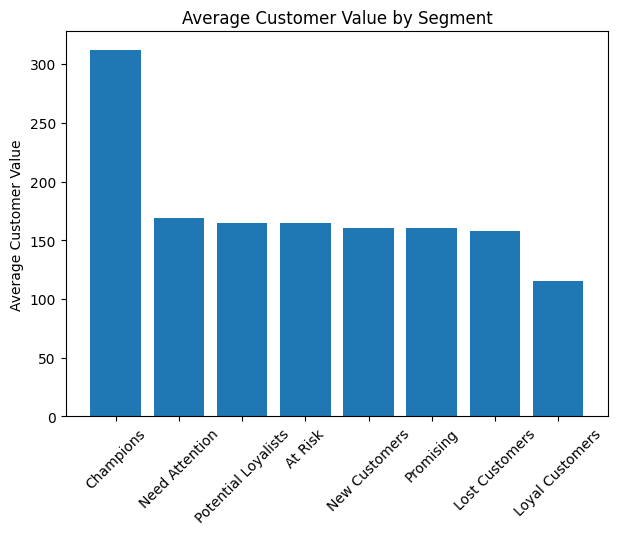

In [ ]:
import matplotlib.pyplot as plt

clv_summary = clv_summary.sort_values(
    by="Avg Customer Value",
    ascending=False
)

plt.figure(figsize=(7,5))

plt.bar(
    clv_summary.index,
    clv_summary["Avg Customer Value"]
)

plt.xticks(rotation=45)
plt.ylabel("Average Customer Value")
plt.title("Average Customer Value by Segment")

plt.show()

In [63]:
rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_Score,Segment,AOV
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112,4,1,4,414,Promising,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115,4,1,1,411,Promising,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537,1,1,2,112,Lost Customers,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321,2,1,1,211,Lost Customers,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288,2,1,4,214,Lost Customers,196.89


In [65]:
rfm["Repeat Customer"] = rfm["frequency"].apply(
    lambda x: "Yes" if x > 1 else "No"
)

In [66]:
rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_Score,Segment,AOV,Repeat Customer
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112,4,1,4,414,Promising,141.90,No
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115,4,1,1,411,Promising,27.19,No
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537,1,1,2,112,Lost Customers,86.22,No
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321,2,1,1,211,Lost Customers,43.62,No
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288,2,1,4,214,Lost Customers,196.89,No


In [67]:
rfm.to_csv(
    "../Exports/customer_analytics.csv",
    index=False
)

# Cohort Analysis

In [70]:
import pandas as pd

cohort = pd.read_csv("../Data/Processed/cohort_data.csv")

cohort.head()

,customer_unique_id,order_purchase_timestamp
0,2e6a42a9b5cbb0da62988694f18ee295,2017-05-15 17:58:25
1,85d234692f7bee8d6fea586e237334b6,2018-05-09 13:01:24
2,8d46223c91cbeb93e0930ca8bd8ffca2,2017-11-26 11:43:57
3,f32cdbbeca0aba5358bddc018dd12b09,2018-04-16 20:46:53
4,be1e99a0c57d7c3c699cfc4db26c8edf,2018-07-31 00:17:40


In [71]:
cohort["order_purchase_timestamp"] = pd.to_datetime(
    cohort["order_purchase_timestamp"]
)

In [73]:
cohort["OrderMonth"] = (
    cohort["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [74]:
cohort.head()

,customer_unique_id,order_purchase_timestamp,OrderMonth
0,2e6a42a9b5cbb0da62988694f18ee295,2017-05-15 17:58:25,2017-05
1,85d234692f7bee8d6fea586e237334b6,2018-05-09 13:01:24,2018-05
2,8d46223c91cbeb93e0930ca8bd8ffca2,2017-11-26 11:43:57,2017-11
3,f32cdbbeca0aba5358bddc018dd12b09,2018-04-16 20:46:53,2018-04
4,be1e99a0c57d7c3c699cfc4db26c8edf,2018-07-31 00:17:40,2018-07


In [75]:
cohort["CohortMonth"] = (
    cohort.groupby("customer_unique_id")["OrderMonth"]
          .transform("min")
)

In [76]:
order_year = cohort["OrderMonth"].dt.year
order_month = cohort["OrderMonth"].dt.month

cohort_year = cohort["CohortMonth"].dt.year
cohort_month = cohort["CohortMonth"].dt.month

cohort["CohortIndex"] = (
    (order_year - cohort_year) * 12
    + (order_month - cohort_month)
    + 1
)

In [77]:
cohort.head()

,customer_unique_id,order_purchase_timestamp,OrderMonth,CohortMonth,CohortIndex
0,2e6a42a9b5cbb0da62988694f18ee295,2017-05-15 17:58:25,2017-05,2017-05,1
1,85d234692f7bee8d6fea586e237334b6,2018-05-09 13:01:24,2018-05,2018-05,1
2,8d46223c91cbeb93e0930ca8bd8ffca2,2017-11-26 11:43:57,2017-11,2017-11,1
3,f32cdbbeca0aba5358bddc018dd12b09,2018-04-16 20:46:53,2018-04,2018-04,1
4,be1e99a0c57d7c3c699cfc4db26c8edf,2018-07-31 00:17:40,2018-07,2018-07,1


In [78]:
cohort_counts = (
    cohort.groupby(
        ["CohortMonth", "CohortIndex"]
    )["customer_unique_id"]
    .nunique()
    .unstack()
)

In [79]:
cohort_size = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(
    cohort_size,
    axis=0
)

retention = (
    retention * 100
).round(1)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


In [80]:
cohort_size = cohort_counts.iloc[:, 0]

valid_cohorts = cohort_size[cohort_size >= 100].index

retention = retention.loc[valid_cohorts]

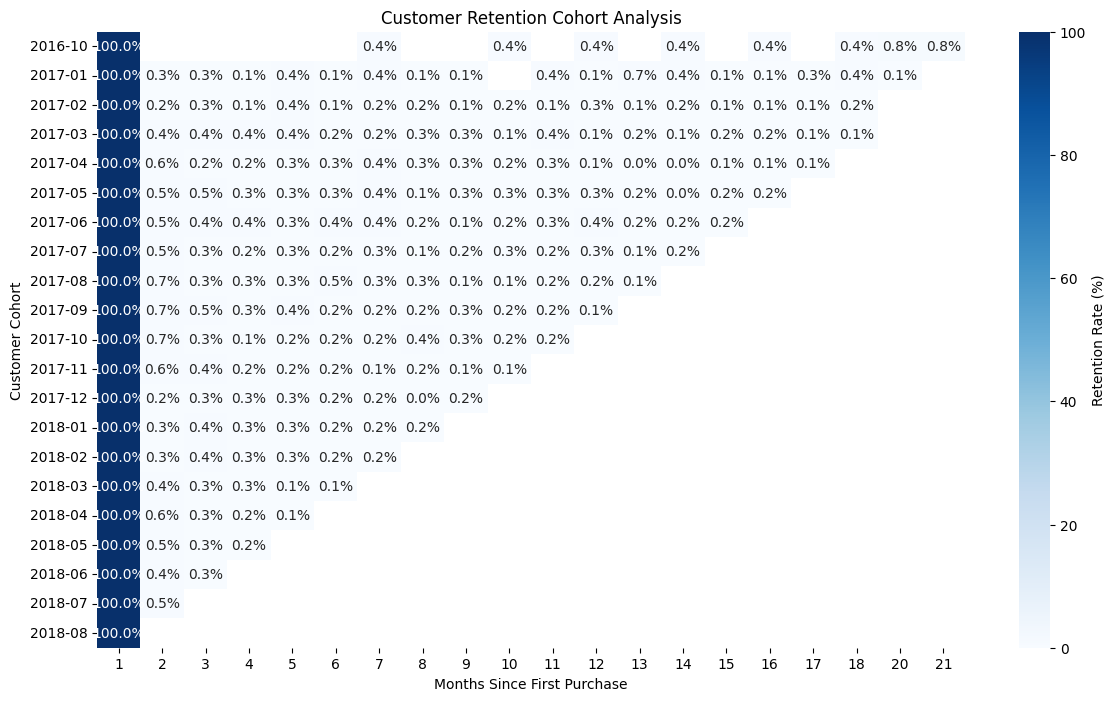

In [81]:
labels = retention.apply(
    lambda col: col.map(
        lambda x: f"{x:.1f}%" if pd.notnull(x) else ""
    )
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))

sns.heatmap(
    retention,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.show()

In [ ]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN


In [91]:
avg_retention = retention.mean()

In [92]:
avg_retention = avg_retention.reset_index()

avg_retention.columns = [
    "Month",
    "Retention"
]

avg_retention.head()

,Month,Retention
0,1,100.000000
1,2,0.468421
2,3,0.344444
3,4,0.247059
4,5,0.287500


In [93]:
avg_retention.to_csv(
    "../Exports/avg_retention.csv",
    index=False
)

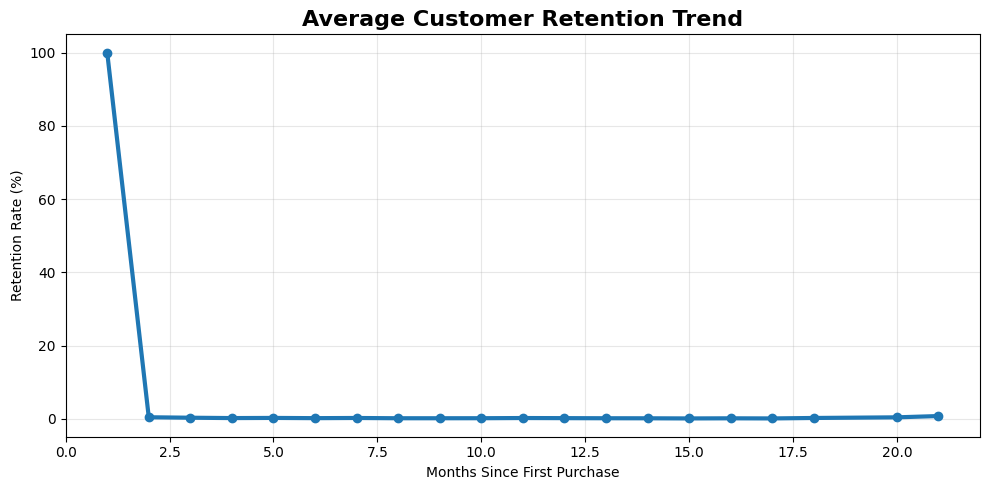

In [87]:
plt.figure(figsize=(10,5))

plt.plot(

    avg_retention["Month"],

    avg_retention["Retention"],

    marker="o",

    linewidth=3

)

plt.title(

    "Average Customer Retention Trend",

    fontsize=16,

    weight="bold"

)

plt.xlabel(

    "Months Since First Purchase"

)

plt.ylabel(

    "Retention Rate (%)"

)

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig(

    "retention_trend.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Dataset Export

In [ ]:
import pandas as pd

executive_summary = pd.DataFrame({

    "Metric":[
        "Revenue",
        "Orders",
        "Customers",
        "Average Order Value"
    ],

    "Value":[
        16008872.12,
        99441,
        96096,
        160.99
    ]

})

executive_summary

,Metric,Value
0,Revenue,16008872.12
1,Orders,99441.00
2,Customers,96096.00
3,Average Order Value,160.99


In [ ]:
executive_summary.to_csv(
    "../Exports/executive_summary.csv",
    index=False
)

In [ ]:
rfm.to_csv(
    "../Exports/customer_segments.csv",
    index=False
)

In [ ]:
retention.to_csv(
    "../Exports/cohort_retention.csv"
)

In [ ]:
clv_summary.to_csv(
    "../Exports/clv_summary.csv",
    index=False
)